# Przewidywanie grup Pokemonów
## Autorzy
- Alicja Knigawka 230979
- Dominik Miernik 230984
- Karolina Kaleta 227850
- Mariusz Jakoniuk 227762
- Urszula Solan 227699
## Słowa kluczowe
Pokemon, drzewa decyzyjne, drzewo decyzyjne, indeks Giniego, klasyfikacja wieloklasowa, las losowy, macierz pomyłek, podział rekurencyjny, random forest, regresja logistyczna, regresja logistyczna wieloklasowa, softmax, standaryzacja danych, walidacja krzyżowa,

## Wprowadzenie
Seria gier Pokemon jest jedną z najpopularniejszych franczyz wyprodukowanych do tej pory.
W grach ziemię, oprócz ludzi, zamieszkują stworki nazywane "Pokemonami".
Mimo uroczego wyglądu, Pokemony są przede wszystkim wykorzystywane do brutalnych walk (pokroju walk psów).
Każdy Pokemon posiada jeden bądź dwa "typy", które wpływają na jego zdolności w walce (np. Pokemon typu "woda" będzie silny w walce przeciwko Pokemonowi typu "ogień").

Dane użyte w badaniu pochodzą z serwisu [Pokemon Database](https://pokemondb.net/), który udostępnia dane z najnowszego wydania gier w postaci pliku YAML. Plik został przez badaczy spłaszczony i przekonwertowany do formatu CSV.

## Przedmiot i cel badania

W badaniu wykorzystano metody uczenia maszynowego (regresję logistyczną, drzewo decyzyjne, lasy losowe oraz model hybrydowy) do przyporządkowywania Pokemonów w pewne "grupy".
Każda grupa jest sumą kilku typów bądź pojedyńczym typem.
Dobór "grup" był arbitralny, badacze na podstawie subiektywnych doświadczeń z grami złączyli ze sobą typy, które z perspektywy gracza wydają się być do siebie "podobne".

W efekcie otrzymano grupy Pokemonów mających w walkach podobne role. Poszczególne grupy i ich cechy zostały omówione w rozdziale "Wstępna analiza danych".

## Wstępna analiza danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
from pygments.styles import manni
from scipy import stats
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Przedstawienie dostępnych zmiennych
Do analizy wybraliśmy następujące cechy:
- `hp` - Maksymalny poziom zdrowia Pokemona (jak wiele punktów obrażeń Pokemon musi przyjąć podczas walki żeby zemdleć)
- `attack`- Ile obrażeń zadaje Pokemon wykonując ataki
- `defense` - Współczynnik zmniejszający otrzymywane obrażenia
- `spatk` - Współczynnik zwiększający zadawane obrażenia przy pomocy ataków specjalnych
- `spdef` - Współczynnik zmniejszający otrzymywane obrażenia od ataków specjalnych
- `speed` - Prędkość Pokemona, wpływa na kolejność tur w bitwie
- `height` - Wysokość Pokemona
- `weight` - Waga Pokemona
- `catch_rate` - Łatwość złapania Pokemona (im większa wartość, tym łatwiej złapać Pokemona)
- `base_exp` - Główny współczynnik określajacy ile punktow doświadczenia Pokemon otrzyma po zakończeniu walki
- `egg_cycle` - Ile kroków należy wykonać aby Pokemon się wykluł z jajka

Badane cechy można podzielić na 3 kategorie:
1. Mające wplyw na efektywność danego Pokemona w walce (`hp`, `attack`, `defense`, `spatk`, `spdef`, `speed`)
2. Określające trudnosć złapania lub rozwijania Pokemona (`catch_rate`, `egg_cycle`, `base_exp`)
3. Mające sens głównie kosmetyczny (`height`, `weight`)

In [2]:
pokemonyMain = pd.read_csv("pokemonyMain_groups.csv")

cechy_names = [
    "group",
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles"
]

cechy_names_without_group = cechy_names[1:]

cechy = pokemonyMain[cechy_names]
description = cechy .describe()
description.loc['skew'] = cechy.skew(numeric_only=True)
description


,hp,attack,defense,spatk,spdef,speed,height,weight,catch_rate,base_exp,egg_cycles
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1214.000000,1214.000000,1192.000000,1192.000000
mean,71.244444,81.152263,75.007407,73.224691,72.441152,70.034568,1.378354,73.883526,90.615321,159.199664,31.040268
std,26.927819,32.037134,30.740999,32.757152,27.578188,30.161298,3.150568,133.733048,75.330475,84.159281,29.139061
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,0.100000,0.100000,3.000000,36.000000,5.000000
25%,52.000000,57.000000,52.000000,50.000000,51.000000,45.000000,0.600000,9.000000,45.000000,68.000000,20.000000
50%,70.000000,80.000000,70.000000,65.000000,70.000000,68.000000,1.000000,30.000000,60.000000,162.000000,20.000000
75%,85.000000,100.000000,91.000000,95.000000,90.000000,91.000000,1.600000,76.375000,120.000000,215.250000,25.000000
max,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,100.000000,999.900000,255.000000,635.000000,120.000000
skew,1.606628,0.416642,1.104015,0.692224,0.871229,0.362885,25.748668,3.997218,0.975258,0.569060,2.473601


### Podział Pokemonów na grupy
Każdy Pokemon ma przypisany do siebie pewien "typ" wpływający na efektywność w walce (np. ataki typu "woda" będą działały ze zwiększoną siłą przeciw Pokemonom typu "ogień"). Typy zachowujące się podobnie w grach zostały przez nas złączone w "grupy":
1. **Średniaki** (typy "water", "poison", "grass", "ice", "normal", "bug") - Pokemony "pospolite", cechujące się wszechstronnością i łatwością złapania.
2. **Grubole** ("ground", "rock", "steel") - Pokemony obronne, potrafiące przyjąć na siebie większą ilość obrażeń, jednocześnie nie uzyskując przy tym większych uszczerbków na zdrowiu
3. **Spejalni** ("electric", "psychic", "fairy", "ghost", "fire") - Pokemony specjalizujące się w walce z Pokemonami specifycznych typów (np. Pokemony typu "electric" specjalizują się w walce z Pokemonami typu "water")
4. **Agresorzy** ("fighting", "dark", "flying") - Pokemony ofensywne, atakujące szybko i zadające wysokie obrażenia
5. **Elita** ("dragon") - Typ "smok" został wydzielony do oddzielnej grupy. Smoki są najsilniejszymi Pokemonami, ale też najtrudniej jest je zdobyć.


Średnie wartości dla grup:

In [3]:
grouped_means = cechy.groupby("group").mean().copy()
grouped_means

,hp,attack,defense,spatk,spdef,speed,height,weight,catch_rate,base_exp,egg_cycles
group,,,,,,,,,,,
agresorzy,73.948276,93.568966,73.025862,64.922414,70.198276,77.724138,1.277586,75.825000,81.879310,164.991379,34.870690
elita,84.571429,103.816327,80.816327,90.122449,83.571429,84.653061,2.038776,121.132653,38.408163,217.265306,63.163265
grubole,70.675000,92.193750,99.012500,64.125000,72.725000,59.756250,1.560625,155.336875,80.512500,163.269231,34.198718
specjalni,68.974194,76.203226,70.825806,88.867742,77.893548,76.580645,1.190323,62.331290,81.864516,170.753247,35.454545
sredniaki,70.948276,76.353448,70.525862,67.606897,68.956897,66.598276,1.392931,53.172366,104.260794,145.504440,24.165187


Poniżej przedstawiono wykres radarowy średnich wartości cech dla każdej ze zdefiniowanych grup. Wartości na wykresach zostały zeskalowane korzystając ze wzoru $z_{ij} = \frac{x_{ij}}{\max(x_i)}$

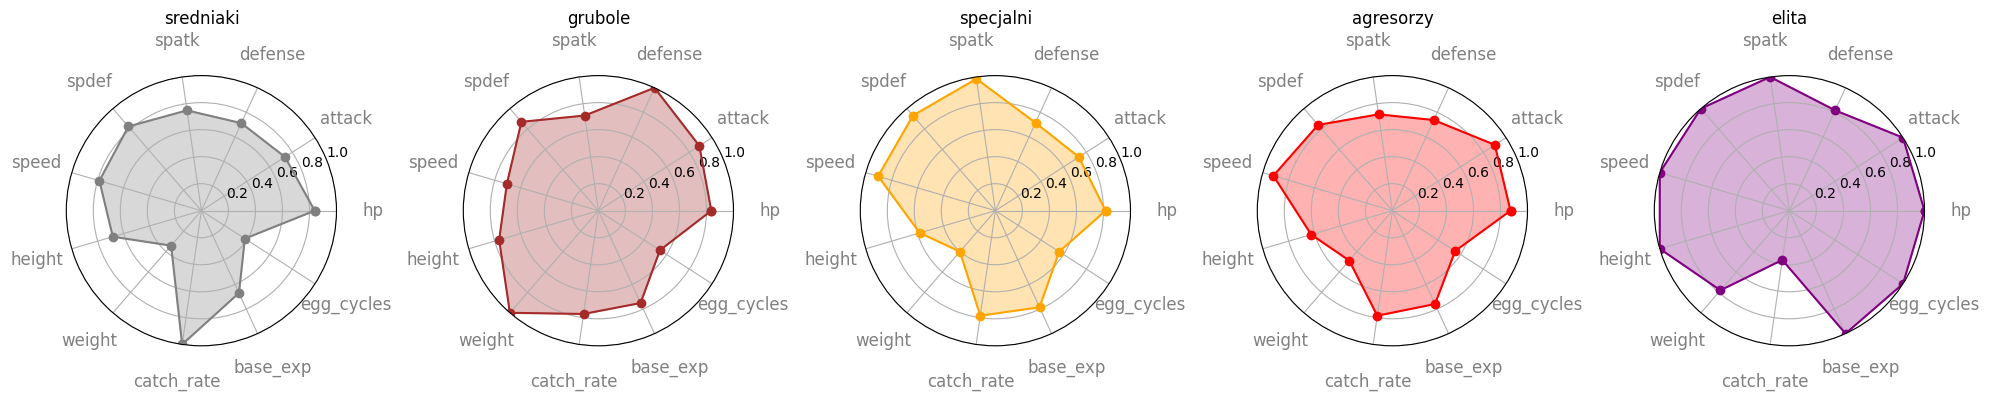

In [4]:
normalized = grouped_means / grouped_means.max().abs()

def radar(ax, group: str, color: str):
    theta = np.arange(len(grouped_means.columns) + 1) / float(len(grouped_means.columns)) * 2 * np.pi
    values = normalized.loc[group].values
    values = np.append(values, values[0])

    ax.plot(theta, values, color=color, marker="o", label="Name of Col B")
    ax.fill(theta, values, color=color, alpha=0.3)
    ax.set_ylim(0, 1)

    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(grouped_means.columns, color='grey', size=12)
    ax.tick_params(pad=16)
    ax.set_title(group)

fig, axes = plt.subplots(nrows = 1, ncols = 5, subplot_kw={'projection': 'polar'}, figsize=(20, 20))

color_mapping = [
    ('sredniaki', 'gray'),
    ('grubole', 'brown'),
    ('specjalni', 'orange'),
    ('agresorzy', 'red'),
    ('elita', 'purple'),
]

for ax, (group, color) in zip(axes, color_mapping):
    radar(ax, group, color)

plt.tight_layout()
plt.show()

## Braki danych i pomiary odstające

Przed trenowaniem modeli, w zbiorze danych znaleziono i usunięto obiekty z brakami w badanych cechach.

In [5]:
original_count = len(pokemonyMain)
pokemonyMain = pokemonyMain.dropna(subset = cechy_names)
new_count = len(pokemonyMain)
print(f"Znaleziono {original_count - new_count} obiekty posiadające braki w badanych cechach")

Znaleziono 24 obiekty posiadające braki w badanych cechach


Odrzucono pomiary ze $z\text{-score} \lt 3$ dla dowolnej z badanych cech.

In [6]:
for col in cechy_names_without_group:
    z = np.abs(stats.zscore(pokemonyMain[col]))
    pokemonyMain = pokemonyMain[z < 3]


print(f"Pomiarów odstających: {new_count - len(pokemonyMain)}")
print(f"Ostateczna lizczba obiektów: {len(pokemonyMain)}")

Pomiarów odstających: 146
Ostateczna lizczba obiektów: 1045


## Opis metod

Dane zostały podzielone na zbiór treningowy (70%) oraz testowy (30%) w celu oceny skuteczności modelu.

In [7]:
cechy = pokemonyMain[cechy_names_without_group]

etykieta = pokemonyMain["group"]

cecha_train, cecha_test, etykieta_train, etykieta_test = train_test_split(
    cechy,
    etykieta,
    test_size=0.3,
    random_state=42
)

### Regresja Logistyczna
Regresja logistyczna wieloklasowa jest modelem klasyfikacyjnym, który oblicza prawdopodobieństwo przynależności obserwacji do każdej z możliwych klas. Dla każdej klasy model wyznacza osobny zestaw wag, a następnie wykorzystuje funkcję softmax, aby zamienić wyniki na wartości z przedziału [0,1], których suma wynosi 1. Klasa o największym prawdopodobieństwie jest wybierana jako wynik predykcji.

Uczenie modelu polega na dopasowaniu wag w taki sposób, aby minimalizować błąd klasyfikacji na danych treningowych, zazwyczaj metodami gradientowymi.

Zastowaliśmy regresję logistyczną wieloklasową wraz ze standaryzacją danych.

In [8]:
modelRegresja = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, solver="lbfgs"))

Trenowanie modelu:

In [9]:
modelRegresja.fit(cecha_train, etykieta_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

## Rezultaty
Poniżej przedstawiono rezultaty użytych metod

### Regresja Liniowa

##### Macierz błędów klasyfikacji dla zbioru treningowego

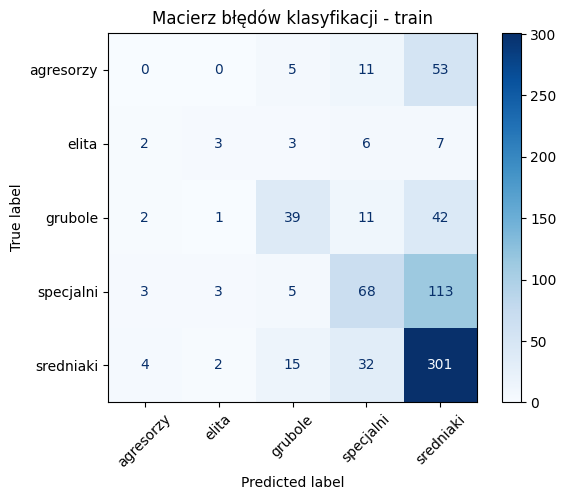

In [10]:
predykcja_train_regresja = modelRegresja.predict(cecha_train)
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_train,
    predykcja_train_regresja,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - train")
plt.savefig("confusion_matrix_train_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

#### Dokładność modelu zbiór - testowy

In [11]:
predykcja_test_regresja = modelRegresja.predict(cecha_test)
print("Accuracy:", accuracy_score(etykieta_test, predykcja_test_regresja))
procent_poprawnych = accuracy_score(etykieta_test, predykcja_test_regresja) * 100
print(f"Procent poprawnych wyników: {procent_poprawnych:.2f}%")


Accuracy: 0.5477707006369427
Procent poprawnych wyników: 54.78%


In [12]:
wyniki = cecha_test.copy()

wyniki["prawdziwa_grupa"] = etykieta_test.values
wyniki["przewidziana_grupa"] = predykcja_test_regresja

wyniki["pokemon"] = pokemonyMain.loc[cecha_test.index, "name"].values

print(wyniki[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))


               pokemon prawdziwa_grupa przewidziana_grupa
860            noivern       agresorzy          sredniaki
302             elekid       specjalni          sredniaki
698            gothita       specjalni          sredniaki
344            shiftry       sredniaki          sredniaki
1151          greavard       specjalni          sredniaki
1035          frosmoth       sredniaki          specjalni
455              bagon           elita            grubole
248             wooper       sredniaki          sredniaki
510     wormadam-sandy       sredniaki          sredniaki
616   samurott-hisuian       sredniaki          sredniaki
380           meditite       agresorzy          sredniaki
177              ditto       sredniaki          sredniaki
722         ferrothorn       sredniaki            grubole
320            torchic       specjalni          sredniaki
283            corsola       sredniaki          sredniaki
392             swalot       sredniaki          sredniaki
652           

#### Macierz błędów klasyfikacji dla zbioru testowego


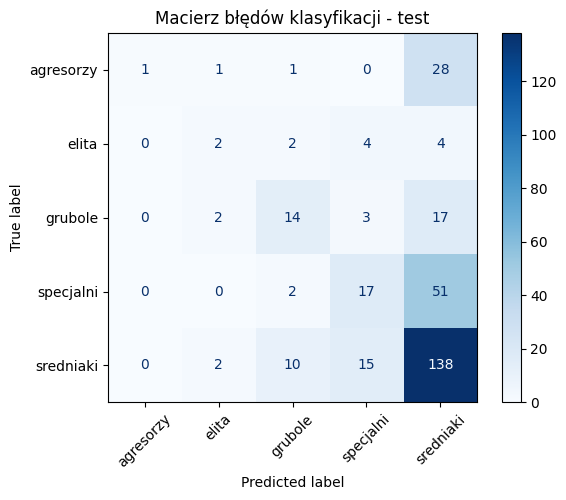

In [13]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test,
    predykcja_test_regresja,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - test")
plt.savefig("confusion_matrix_test_regresja.png", dpi=300, bbox_inches="tight")
plt.show()

## Biblliografia

- Jackowska, Beata (2011), Efekty interakcji między zmiennymi objaśniającymi w modelu logitowym w analizie zróżnicowania ryzyka zgonu, Przegląd Statystyczny, R. LVIII, z. 1–2

- Zięba, M. (2019). Modele liniowe [materiały dydaktyczne, wykład RO_W4]. Politechnika Wrocławska.